In [22]:
"""Stages, commit, and push notebook changes to GitHub."""

import subprocess
import datetime

def auto_push(message=None):
    if not message:
        # Commit message with current date and time
        message = f"Auto-save: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}"
  
    try:
        # 1. Check if there are any changes in the folder right now
        status_before = subprocess.run(["git", "status", "--porcelain"], capture_output=True, text=True, check=True)
        
        # 2. Only stage and commit if files have actually changed
        if status_before.stdout.strip():
            subprocess.run(["git", "add", "."], check=True)
            subprocess.run(["git", "commit", "-m", message], check=True)
            print(f"📝 Created 1 clean commit: '{message}'")
        else:
            print("ℹ️ No new file changes detected.")
            
        # 3. Push your single clean commit online
        print("🚀 Uploading to GitHub...")
        subprocess.run(["git", "push", "origin", "main"], check=True)
        print("✅ Successfully synced and pushed to GitHub!")
        
    except subprocess.CalledProcessError as e:
        print(f"❌ Git automation failed: {e}")


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

# 1. Load data
df = pd.read_csv("../data/Churn_Modelling.csv")

# 2. Quick look
df.head()
df.info()
df.describe()
df['Exited'].value_counts(normalize=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

**BASIC UNIVARIATE PLOTS**

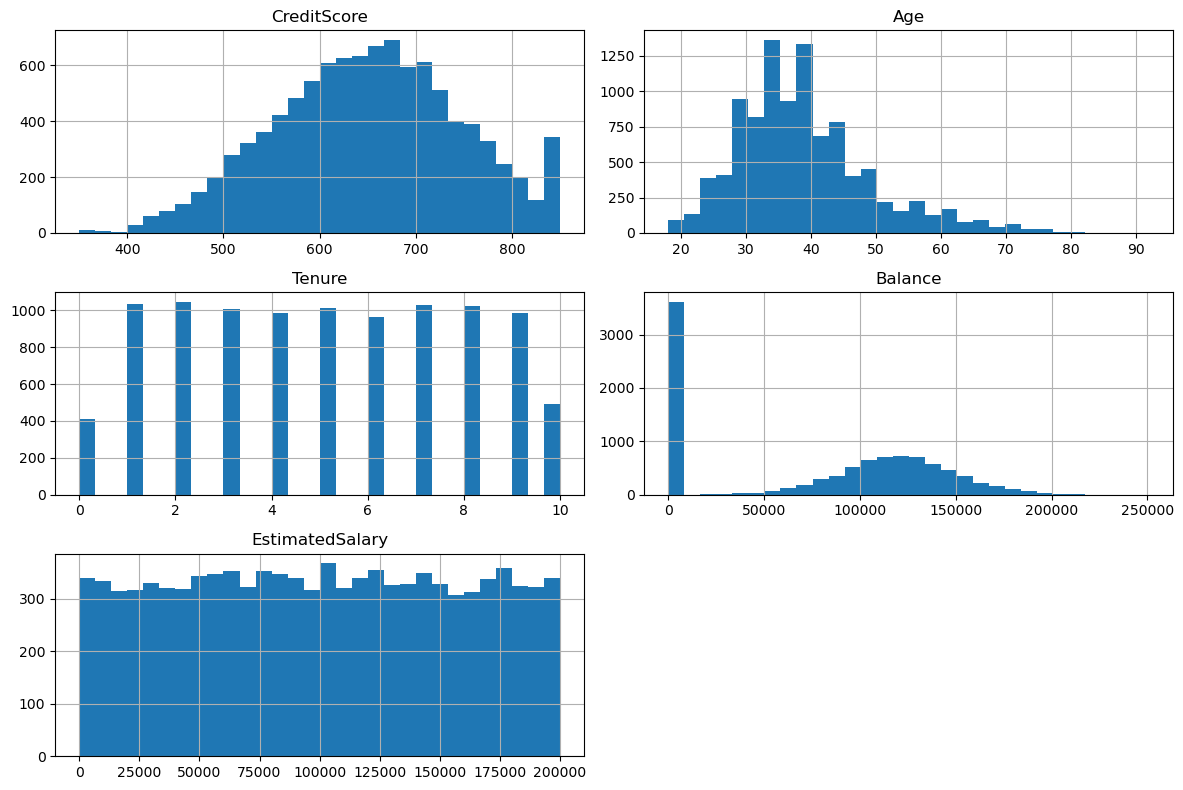

In [10]:
# Numerical distributions
num_cols = ["CreditScore", "Age", "Tenure", "Balance", "EstimatedSalary"]
df[num_cols].hist(bins=30, figsize=(12, 8))
plt.tight_layout()

# Churn distribution
df['Exited'].value_counts().plot(kind="bar")
plt.title("Churn (Exited) distribution")
plt.xticks(rotation=0)
plt.show()



**CHURN VS KEY FEATURES:**



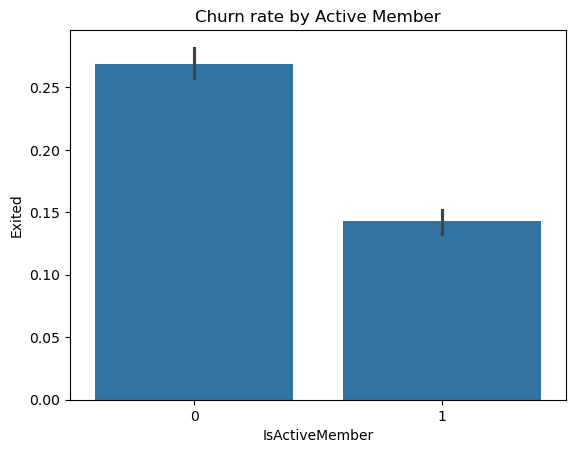

In [11]:
# Churn rate by Geography
df.groupby("Geography")["Exited"].mean().sort_values(ascending=False)

# Bar plot: churn rate by IsActiveMember
sns.barplot(
    data=df,
    x="IsActiveMember",
    y="Exited",
    estimator=np.mean
)
plt.title("Churn rate by Active Member")
plt.show()

In [25]:
 auto_push("Finished EDA")

[main 4a6f881] Finished EDA
 1 file changed, 16 insertions(+), 32 deletions(-)
📝 Created 1 clean commit: 'Finished EDA'
🚀 Uploading to GitHub...
❌ Git automation failed: Command '['git', 'push', 'origin', 'main']' returned non-zero exit status 1.


remote: error: GH013: Repository rule violations found for refs/heads/main.        
remote: 
remote: - GITHUB PUSH PROTECTION        
remote:   —————————————————————————————————————————        
remote:     Resolve the following violations before pushing again        
remote: 
remote:     - Push cannot contain secrets        
remote: 
remote:             
remote:      (?) Learn how to resolve a blocked push        
remote:      https://docs.github.com/code-security/secret-scanning/working-with-secret-scanning-and-push-protection/working-with-push-protection-from-the-command-line#resolving-a-blocked-push        
remote:             
remote:             
remote:       —— GitHub Personal Access Token ——————————————————————        
remote:        locations:        
remote:          - commit: 5f38dffb27802a3e0a3be2d7b67977612ff519b6        
remote:            path: src/EDA.ipynb:14        
remote:          - commit: 4a6f8814ec63bdec4f214c4cb50f60b176c1f1de        
remote:            path: sr